In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),
    HybridPoolingV0(30,nn.AvgPool2d,nn.MaxPool2d),          # 32 → 16

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    HybridPoolingV0(60,nn.AvgPool2d,nn.MaxPool2d),          # 16 → 8

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    HybridPoolingV0(60,nn.AvgPool2d,nn.MaxPool2d),          # 8 → 4

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    HybridPoolingV0(60,nn.AvgPool2d,nn.MaxPool2d),          # 4 → 2

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model40_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model40_0)
describe(model40_0)

MACs: 4.57 MMac, Params: 24.99 k
Layer (type:depth-idx)                        Output Shape              Param #
BaseModelF32                                  [1, 10]                   --
├─ModuleList: 1-1                             --                        --
│    └─Sequential: 2-1                        [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1                  [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                       [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9                  [1, 30, 32, 32] 

Loading checkpoint from model_weights/model40_0.pt
Starting
Epoch 1/60: Train loss = 1.1790, Train accuracy = 0.5791, Test loss = 1.1591, Test accuracy = 0.5895
Epoch 2/60: Train loss = 0.9026, Train accuracy = 0.6857, Test loss = 0.8770, Test accuracy = 0.6961
Epoch 3/60: Train loss = 0.7888, Train accuracy = 0.7263, Test loss = 0.7821, Test accuracy = 0.7260
Epoch 4/60: Train loss = 0.7275, Train accuracy = 0.7451, Test loss = 0.7334, Test accuracy = 0.7467
Epoch 5/60: Train loss = 0.6643, Train accuracy = 0.7676, Test loss = 0.6594, Test accuracy = 0.7685
Epoch 6/60: Train loss = 0.7305, Train accuracy = 0.7487, Test loss = 0.8082, Test accuracy = 0.7357
Epoch 7/60: Train loss = 0.6143, Train accuracy = 0.7873, Test loss = 0.6496, Test accuracy = 0.7802
Epoch 8/60: Train loss = 0.5612, Train accuracy = 0.8053, Test loss = 0.5862, Test accuracy = 0.8018
Epoch 9/60: Train loss = 0.6245, Train accuracy = 0.7912, Test loss = 0.6614, Test accuracy = 0.7795
Epoch 10/60: Train loss = 0.536

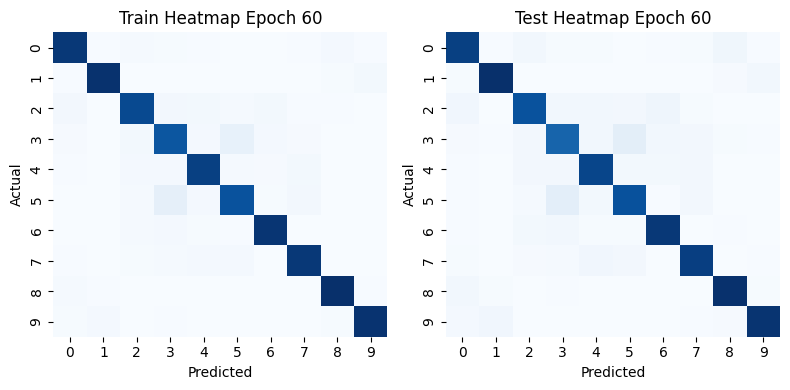

<Figure size 1200x600 with 0 Axes>

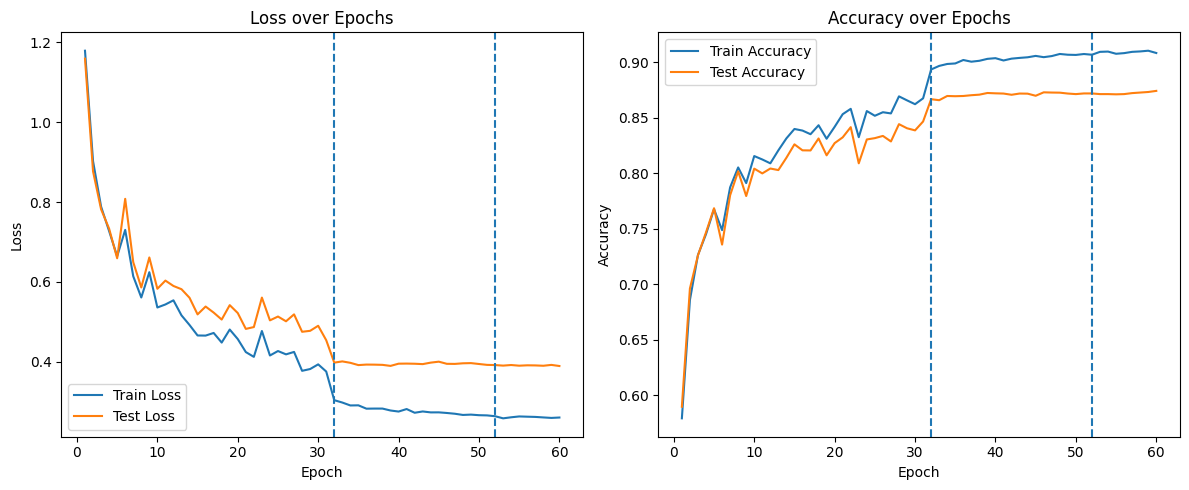

In [6]:
trainf32(model40_0,"model_weights/model40_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model40_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model40_1)
describe(model40_1)

MACs: 4.57 MMac, Params: 24.99 k
Layer (type:depth-idx)                        Output Shape              Param #
BaseModelF32                                  [1, 10]                   --
├─ModuleList: 1-1                             --                        --
│    └─Sequential: 2-1                        [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1                  [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                       [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9                  [1, 30, 32, 32] 

Loading checkpoint from model_weights/model40_1.pt
Starting
Epoch 1/60: Train loss = 0.9934, Train accuracy = 0.6530, Test loss = 0.9812, Test accuracy = 0.6618
Epoch 2/60: Train loss = 0.8070, Train accuracy = 0.7198, Test loss = 0.7877, Test accuracy = 0.7293
Epoch 3/60: Train loss = 0.6688, Train accuracy = 0.7680, Test loss = 0.6735, Test accuracy = 0.7661
Epoch 4/60: Train loss = 0.6744, Train accuracy = 0.7683, Test loss = 0.6962, Test accuracy = 0.7588
Epoch 5/60: Train loss = 0.5945, Train accuracy = 0.7932, Test loss = 0.6222, Test accuracy = 0.7850
Epoch 6/60: Train loss = 0.5480, Train accuracy = 0.8121, Test loss = 0.5802, Test accuracy = 0.8021
Epoch 7/60: Train loss = 0.5387, Train accuracy = 0.8118, Test loss = 0.5700, Test accuracy = 0.8062
Epoch 8/60: Train loss = 0.5006, Train accuracy = 0.8250, Test loss = 0.5408, Test accuracy = 0.8154
Epoch 9/60: Train loss = 0.5253, Train accuracy = 0.8176, Test loss = 0.5642, Test accuracy = 0.8079
Epoch 10/60: Train loss = 0.465

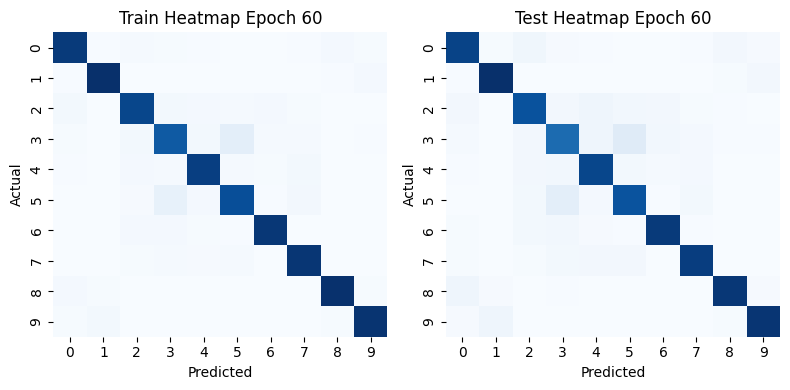

<Figure size 1200x600 with 0 Axes>

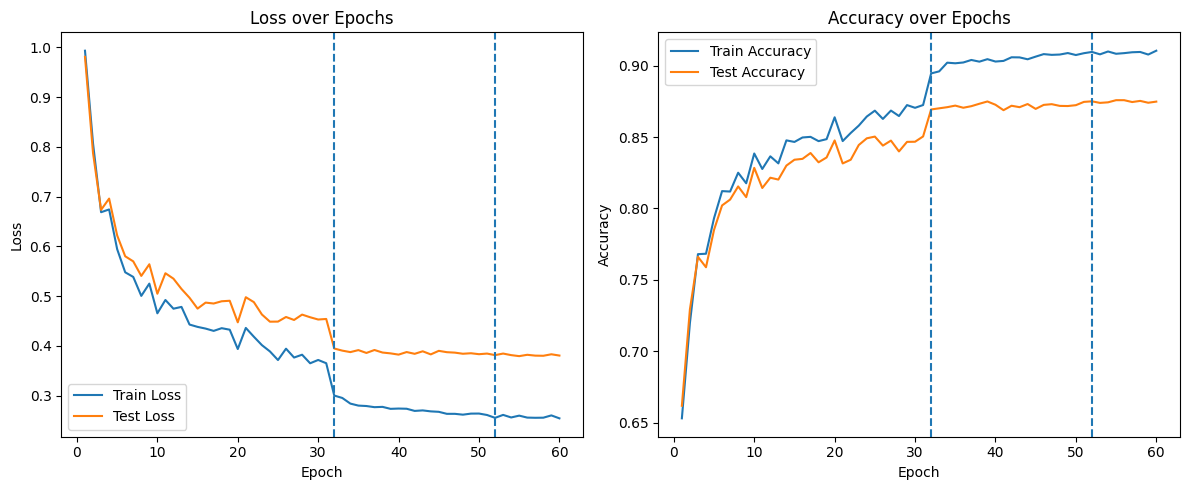

In [8]:
trainf32(model40_1,"model_weights/model40_1.pt",criterion,train_dataset,val_dataset, batch_size=64)